## Mall Customers

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
print('Libraries imported')

Libraries imported


In [11]:
df=pd.read_csv('./dataset.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [12]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

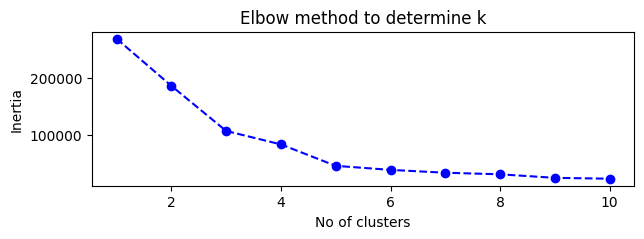

In [16]:
X=df.drop(['CustomerID','Gender','Age'],axis=1)
inertia=[]
k_range=range(1,11)
for k in k_range:
    model=KMeans(n_clusters=k)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(7,2))
plt.plot(k_range,inertia,marker='o',linestyle='--',color='b')
plt.title('Elbow method to determine k')
plt.xlabel('No of clusters')
plt.ylabel('Inertia')
plt.show()

In [17]:
kmeans=KMeans(n_clusters=5,random_state=42)
df['Cluster']=kmeans.fit_predict(X)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


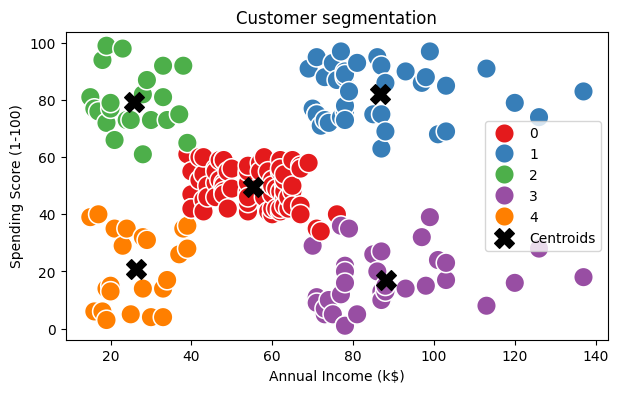

In [19]:
plt.figure(figsize=(7,4))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=200
)

centers=kmeans.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],c='black',s=200,marker='X', label='Centroids')
plt.title('Customer segmentation')
plt.legend()
plt.show()

In [22]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_summary)


df['Cluster'].value_counts()

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64